In [1]:
from graph_building_claude import *

In [2]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from music21 import converter
from music21 import layout
from music21 import expressions

In [23]:
import ipywidgets as widgets
from IPython.display import display, clear_output, Audio
from music21 import converter, stream, expressions, note, chord, environment
import copy
import tempfile
import os
from pygame import mixer
import time

In [3]:
def visualize_segment(segments, segment_index, original_score, show_score=True):
    """
    Modified version of the original visualize_segment function that removes title elements,
    adds segment number, and controls display
    
    Parameters:
    segments (list): List of pandas DataFrames containing segment information
    segment_index (int): Index of the segment to visualize
    original_score (music21.stream.Score): The original score to maintain structure
    show_score (bool): Whether to automatically display the score
    
    Returns:
    music21.stream.Score: The modified score showing only the segment notes
    """
    # Define the color map for IR symbols
    color_map = {
        'P': 'blue',      # IR1: P (Process)
        'D': 'green',     # IR2: D (Duplication)
        'IP': 'red',      # IR3: IP (Intervallic Process)
        'ID': 'orange',   # IR4: ID (Intervallic Duplication)
        'VP': 'purple',   # IR5: VP (Vector Process)
        'R': 'cyan',      # IR6: R (Reversal)
        'IR': 'magenta',  # IR7: IR (Intervallic Reversal)
        'VR': 'yellow',   # IR8: VR (Vector Reversal)
        'M': 'pink',      # IR9: M (Monad)
        'd': 'lime',      # IR10 d (Dyad)
        'rest': 'black'   # Default color for rests
    }
    
    if not isinstance(segments, list) or segment_index >= len(segments):
        raise ValueError(f"Invalid segment index. Must be between 0 and {len(segments)-1}")
    
    # Make a deep copy of the original score to preserve its structure
    # new_score = copy.deepcopy(original_score)
    # 
    # # Remove all TextBox elements and TextExpressions from the score
    # for part in new_score.parts:
    #     for measure in part.recurse().getElementsByClass('Measure'):
    #         for elem in measure.getElementsByClass(['TextExpression', 'TextBox']):
    #             measure.remove(elem)
    #     
    #     # Also check for text elements directly in the part
    #     for elem in part.getElementsByClass(['TextExpression', 'TextBox']):
    #         part.remove(elem)
    # 
    # # Check for any text elements in the score itself
    # for elem in new_score.getElementsByClass(['TextExpression', 'TextBox']):
    #     new_score.remove(elem)
    # 
    # # Remove all TextBox elements and TextExpressions from the score
    # for elem in new_score.recurse().getElementsByClass(['TextExpression', 'TextBox']):
    #     elem.activeSite.remove(elem)
    #     
    # # Remove metadata (including filename/title)
    # new_score.metadata = None
    
    # Make a deep copy of the original score to preserve its structure
    score = copy.deepcopy(original_score)
    
    # Create a completely new score
    new_score = stream.Score()
    
    # First check if we have any staff groups (like piano's grand staff)
    part_groups = []
    for element in score.elements:
        if isinstance(element, layout.StaffGroup):
            part_groups.append(copy.deepcopy(element))
    
    # Add any staff groups to the new score first
    for group in part_groups:
        new_score.append(group)
    
    # Copy parts while preserving their relationships
    for part in score.parts:
        new_part = stream.Part()
        
        # Preserve staff layout information
        for elem in part.getElementsByClass('LayoutClass'):
            new_part.append(copy.deepcopy(elem))
        
        # Copy measures and their contents
        for measure in part.getElementsByClass('Measure'):
            new_measure = stream.Measure()
            new_measure.number = measure.number
            
            # Copy time signature if it exists
            ts = measure.timeSignature
            if ts:
                new_measure.timeSignature = copy.deepcopy(ts)
            # Copy clef if it exists
            cl = measure.clef
            if cl:
                new_measure.clef = copy.deepcopy(cl)
            # Copy key signature if it exists
            ks = measure.keySignature
            if ks:
                new_measure.keySignature = copy.deepcopy(ks)
                
            # Copy notes, rests, and chords
            for elem in measure.getElementsByClass(['Note', 'Rest', 'Chord']):
                new_measure.append(copy.deepcopy(elem))
                
            new_part.append(new_measure)
            
        # Preserve any staff identifiers or group memberships
        if hasattr(part, 'staffName'):
            new_part.staffName = part.staffName
        if hasattr(part, 'groupName'):
            new_part.groupName = part.groupName
            
        new_score.append(new_part)
    
    # Add segment number as a text expression at the top
    
    segment_text = expressions.TextExpression(f'Segment {segment_index}')
    segment_text.style.absoluteY = 75  # Position above the staff
    segment_text.style.fontSize = 14
    first_measure = new_score.parts[0].getElementsByClass('Measure')[0]
    first_measure.insert(0, segment_text)
    
    # Get the selected segment
    segment = segments[segment_index]
    
    # Create a set of onsets in the segment for quick lookup
    segment_onsets = set(segment['onset_beats'].values)
    
    # Iterate over the parts of the new_score
    for part in new_score.parts:
        measures_to_keep = []
        # First pass: identify measures with segment notes and transform notes
        for measure in part.getElementsByClass(stream.Measure):
            has_segment_notes = False
            for element in measure:
                if isinstance(element, (note.Note, note.Rest, chord.Chord)):
                    element_offset = element.getOffsetInHierarchy(new_score)
                    
                    if element_offset in segment_onsets:
                        has_segment_notes = True
                        # Find the corresponding row in our segment DataFrame
                        segment_row = segment[segment['onset_beats'] == element_offset].iloc[0]
                        
                        # If it's a rest in our segment data
                        if segment_row['midi_pitch'] == 0:
                            new_element = note.Rest(quarterLength=element.duration.quarterLength)
                            new_element.style.color = color_map['rest']
                        else:
                            # Create a new note with the pitch from our segment
                            new_element = note.Note(
                                pitch=segment_row['midi_pitch'],
                                quarterLength=element.duration.quarterLength
                            )
                            
                            # Add IR symbol and color if available
                            if 'ir_symbol' in segment_row:
                                ir_symbol = segment_row['ir_symbol']
                                new_element.lyric = ir_symbol
                                if ir_symbol in color_map:
                                    new_element.style.color = color_map[ir_symbol]
                        
                        # Replace the element in the measure
                        measure.replace(element, new_element)
                    else:
                        # Remove notes not in our segment
                        measure.remove(element)
            
            if has_segment_notes:
                measures_to_keep.append(measure)
        
        # Clear all measures from the part
        for measure in part.getElementsByClass(stream.Measure):
            part.remove(measure)
        
        # Add back only the measures we want to keep
        for measure in measures_to_keep:
            part.append(measure)
            
        # If the part is empty after removing measures, remove it from the score
        if len(part.getElementsByClass(stream.Measure)) == 0:
            new_score.remove(part)
    
    
    
    # Show the updated score if requested
    if show_score:
        new_score.show()
    
    return new_score

In [4]:
class SegmentComparisonVisualizer:
    def __init__(self, segments, original_score):
        self.segments = segments
        self.original_score = original_score
        self.setup_widgets()
        
    def setup_widgets(self):
        # Create dropdowns for segment selection
        self.segment1_dropdown = widgets.Dropdown(
            options=[(f'Segment {i}', i) for i in range(len(self.segments))],
            value=0,
            description='Segment 1:',
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='250px')
        )
        
        # Checkbox to enable/disable comparison
        self.enable_comparison = widgets.Checkbox(
            value=False,
            description='Compare with another segment',
            layout=widgets.Layout(width='250px')
        )
        
        # Second segment dropdown (initially hidden)
        self.segment2_dropdown = widgets.Dropdown(
            options=[(f'Segment {i}', i) for i in range(len(self.segments))],
            value=1,
            description='Segment 2:',
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='250px', visibility='hidden')
        )
        
        # Create an update button
        self.update_button = widgets.Button(
            description='Update Visualization',
            button_style='primary',
            layout=widgets.Layout(width='200px')
        )
        
        # Create info areas for each segment
        self.info_area1 = widgets.HTML(
            value='<p>Select first segment to view details</p>',
            layout=widgets.Layout(width='100%', padding='10px')
        )
        
        self.info_area2 = widgets.HTML(
            value='',
            layout=widgets.Layout(width='100%', padding='10px', visibility='hidden')
        )
        
        # Create output areas for each visualization
        self.output1 = widgets.Output()
        self.output2 = widgets.Output()
        
        # Add callbacks
        self.update_button.on_click(self.update_visualization)
        self.enable_comparison.observe(self.toggle_comparison_view, names='value')
        
        # Layout the widgets
        self.controls = widgets.HBox([
            self.segment1_dropdown,
            self.enable_comparison,
            self.segment2_dropdown,
            self.update_button
        ])
        
        self.info_box = widgets.VBox([self.info_area1, self.info_area2])
        self.output_box = widgets.VBox([self.output1, self.output2])
        
        self.widget_box = widgets.VBox([
            self.controls,
            self.info_box,
            self.output_box
        ])
        
        # Display the interface
        display(self.widget_box)
    
    def toggle_comparison_view(self, change):
        """Toggle visibility of comparison-related widgets"""
        visibility = 'visible' if change['new'] else 'hidden'
        self.segment2_dropdown.layout.visibility = visibility
        self.info_area2.layout.visibility = visibility
        if not change['new']:
            with self.output2:
                clear_output()
    
    def get_segment_info(self, segment_idx):
        """Generate HTML info for a segment"""
        segment_df = self.segments[segment_idx]
        return f"""
        <div style='background-color: #f0f0f0; padding: 10px; border-radius: 5px;'>
            <h4>Segment {segment_idx} Details:</h4>
            <ul>
                <li>Number of notes: {len(segment_df)}</li>
                <li>Duration (beats): {segment_df['onset_beats'].max() - segment_df['onset_beats'].min():.2f}</li>
            </ul>
        </div>
        """
    
    def visualize_segments(self):
        """Visualize one or two segments based on current selection"""
        # Update first segment
        with self.output1:
            clear_output(wait=True)
            segment1_score = visualize_segment(
                self.segments,
                self.segment1_dropdown.value,
                self.original_score,
                show_score=False  # Prevent automatic display
            )
            segment1_score.show()
        self.info_area1.value = self.get_segment_info(self.segment1_dropdown.value)
        
        # Update second segment if comparison is enabled
        if self.enable_comparison.value:
            with self.output2:
                clear_output(wait=True)
                segment2_score = visualize_segment(
                    self.segments,
                    self.segment2_dropdown.value,
                    self.original_score,
                    show_score=False  # Prevent automatic display
                )
                segment2_score.show()
            self.info_area2.value = self.get_segment_info(self.segment2_dropdown.value)
        else:
            self.info_area2.value = ''
    
    def update_visualization(self, _=None):
        self.visualize_segments()

In [24]:
class MultiSegmentVisualizer:
    def __init__(self, segments, original_score, max_segments=4):
        self.segments = segments
        self.original_score = original_score
        self.max_segments = max_segments
        self.active_segments = 1
        self.segment_widgets = []
        self.current_scores = [None] * max_segments
        self.setup_widgets()
        
    def create_segment_controls(self, index):
        """Create a set of controls for a single segment"""
        segment_box = widgets.VBox([
            widgets.HBox([
                widgets.Dropdown(
                    options=[(f'Segment {i}', i) for i in range(len(self.segments))],
                    value=index,  # Set different default values for each dropdown
                    description=f'Segment {index + 1}:',
                    style={'description_width': 'initial'},
                    layout=widgets.Layout(width='250px')
                ),
                widgets.Button(
                    description=f'Play Segment {index + 1}',
                    button_style='success',
                    layout=widgets.Layout(width='150px')
                )
            ]),
            widgets.HTML(
                value=f'<p>Select segment {index + 1} to view details</p>',
                layout=widgets.Layout(width='100%', padding='10px')
            ),
            widgets.Output()
        ])
        
        # Add play button callback
        segment_box.children[0].children[1].on_click(
            lambda b, idx=index: self.play_segment(idx)
        )
        
        return segment_box
    
    def setup_widgets(self):
        # Create add/remove segment controls
        self.add_segment_btn = widgets.Button(
            description='Add Segment',
            button_style='info',
            layout=widgets.Layout(width='150px')
        )
        
        self.remove_segment_btn = widgets.Button(
            description='Remove Segment',
            button_style='warning',
            layout=widgets.Layout(width='150px')
        )
        
        self.update_button = widgets.Button(
            description='Update All',
            button_style='primary',
            layout=widgets.Layout(width='150px')
        )
        
        # Add callbacks
        self.add_segment_btn.on_click(self.add_segment)
        self.remove_segment_btn.on_click(self.remove_segment)
        self.update_button.on_click(self.update_visualization)
        
        # Create first segment controls
        self.segment_widgets.append(self.create_segment_controls(0))
        
        # Create control panel
        self.controls = widgets.HBox([
            self.add_segment_btn,
            self.remove_segment_btn,
            self.update_button
        ])
        
        # Layout all widgets
        self.widget_box = widgets.VBox([
            self.controls,
            widgets.VBox(self.segment_widgets)
        ])
        
        # Display the interface
        display(self.widget_box)
    
    def add_segment(self, _):
        """Add a new segment comparison if under max limit"""
        if self.active_segments < self.max_segments:
            new_segment = self.create_segment_controls(self.active_segments)
            self.segment_widgets.append(new_segment)
            self.active_segments += 1
            self.widget_box.children = (
                self.controls,
                widgets.VBox(self.segment_widgets)
            )
    
    def remove_segment(self, _):
        """Remove the last segment comparison if more than one exists"""
        if self.active_segments > 1:
            removed_segment = self.segment_widgets.pop()
            self.active_segments -= 1
            self.current_scores[self.active_segments] = None
            self.widget_box.children = (
                self.controls,
                widgets.VBox(self.segment_widgets)
            )
    
    def play_segment(self, index):
        """Play MIDI for the specified segment"""
        if self.current_scores[index]:
            self.current_scores[index].show('midi')
    
    def get_segment_info(self, segment_idx):
        """Generate HTML info for a segment"""
        segment_df = self.segments[segment_idx]
        return f"""
        <div style='background-color: #f0f0f0; padding: 10px; border-radius: 5px;'>
            <h4>Segment {segment_idx} Details:</h4>
            <ul>
                <li>Number of notes: {len(segment_df)}</li>
                <li>Duration (beats): {segment_df['onset_beats'].max() - segment_df['onset_beats'].min():.2f}</li>
            </ul>
        </div>
        """
    
    def update_visualization(self, _=None):
        """Update all active segment visualizations"""
        for idx, segment_box in enumerate(self.segment_widgets):
            # Get the selected segment index from the dropdown
            selected_segment = segment_box.children[0].children[0].value
            
            # Update info
            segment_box.children[1].value = self.get_segment_info(selected_segment)
            
            # Update visualization
            with segment_box.children[2]:
                clear_output(wait=True)
                self.current_scores[idx] = visualize_segment(
                    self.segments,
                    selected_segment,
                    self.original_score,
                    show_score=False
                )
                self.current_scores[idx].show()

In [16]:
class SegmentComparisonVisualizer:
    def __init__(self, segments, original_score):
        self.segments = segments
        self.original_score = original_score
        self.current_score1 = None
        self.current_score2 = None
        self.setup_widgets()
        
    def setup_widgets(self):
        # Create dropdowns for segment selection
        self.segment1_dropdown = widgets.Dropdown(
            options=[(f'Segment {i}', i) for i in range(len(self.segments))],
            value=0,
            description='Segment 1:',
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='250px')
        )
        
        # Create play buttons for MIDI playback
        self.play_button1 = widgets.Button(
            description='Play Segment 1',
            button_style='success',
            layout=widgets.Layout(width='150px')
        )
        
        self.play_button2 = widgets.Button(
            description='Play Segment 2',
            button_style='success',
            layout=widgets.Layout(width='150px', visibility='hidden')
        )
        
        # Checkbox to enable/disable comparison
        self.enable_comparison = widgets.Checkbox(
            value=False,
            description='Compare with another segment',
            layout=widgets.Layout(width='250px')
        )
        
        # Second segment dropdown (initially hidden)
        self.segment2_dropdown = widgets.Dropdown(
            options=[(f'Segment {i}', i) for i in range(len(self.segments))],
            value=1,
            description='Segment 2:',
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='250px', visibility='hidden')
        )
        
        # Create an update button
        self.update_button = widgets.Button(
            description='Update Visualization',
            button_style='primary',
            layout=widgets.Layout(width='200px')
        )
        
        # Create info areas for each segment
        self.info_area1 = widgets.HTML(
            value='<p>Select first segment to view details</p>',
            layout=widgets.Layout(width='100%', padding='10px')
        )
        
        self.info_area2 = widgets.HTML(
            value='',
            layout=widgets.Layout(width='100%', padding='10px', visibility='hidden')
        )
        
        # Create output areas for each visualization
        self.output1 = widgets.Output()
        self.output2 = widgets.Output()
        
        # Add callbacks
        self.update_button.on_click(self.update_visualization)
        self.enable_comparison.observe(self.toggle_comparison_view, names='value')
        self.play_button1.on_click(self.play_segment1)
        self.play_button2.on_click(self.play_segment2)
        
        # Layout the widgets
        self.controls = widgets.HBox([
            widgets.VBox([
                self.segment1_dropdown,
                self.play_button1
            ]),
            self.enable_comparison,
            widgets.VBox([
                self.segment2_dropdown,
                self.play_button2
            ]),
            self.update_button
        ])
        
        self.info_box = widgets.VBox([self.info_area1, self.info_area2])
        self.output_box = widgets.VBox([self.output1, self.output2])
        
        self.widget_box = widgets.VBox([
            self.controls,
            self.info_box,
            self.output_box
        ])
        
        # Display the interface
        display(self.widget_box)
    
    def play_segment1(self, _):
        """Play MIDI for segment 1"""
        if self.current_score1:
            self.current_score1.show('midi')
    
    def play_segment2(self, _):
        """Play MIDI for segment 2"""
        if self.current_score2:
            self.current_score2.show('midi')
    
    def toggle_comparison_view(self, change):
        """Toggle visibility of comparison-related widgets"""
        visibility = 'visible' if change['new'] else 'hidden'
        self.segment2_dropdown.layout.visibility = visibility
        self.info_area2.layout.visibility = visibility
        self.play_button2.layout.visibility = visibility
        if not change['new']:
            with self.output2:
                clear_output()
            self.current_score2 = None
    
    def get_segment_info(self, segment_idx):
        """Generate HTML info for a segment"""
        segment_df = self.segments[segment_idx]
        return f"""
        <div style='background-color: #f0f0f0; padding: 10px; border-radius: 5px;'>
            <h4>Segment {segment_idx} Details:</h4>
            <ul>
                <li>Number of notes: {len(segment_df)}</li>
                <li>Duration (beats): {segment_df['onset_beats'].max() - segment_df['onset_beats'].min():.2f}</li>
            </ul>
        </div>
        """
    
    def visualize_segments(self):
        """Visualize one or two segments based on current selection"""
        # Update first segment
        with self.output1:
            clear_output(wait=True)
            self.current_score1 = visualize_segment(
                self.segments,
                self.segment1_dropdown.value,
                self.original_score,
                show_score=False  # Prevent automatic display
            )
            self.current_score1.show()
        self.info_area1.value = self.get_segment_info(self.segment1_dropdown.value)
        
        # Update second segment if comparison is enabled
        if self.enable_comparison.value:
            with self.output2:
                clear_output(wait=True)
                self.current_score2 = visualize_segment(
                    self.segments,
                    self.segment2_dropdown.value,
                    self.original_score,
                    show_score=False  # Prevent automatic display
                )
                self.current_score2.show()
            self.info_area2.value = self.get_segment_info(self.segment2_dropdown.value)
        else:
            self.info_area2.value = ''
            self.current_score2 = None
    
    def update_visualization(self, _=None):
        self.visualize_segments()


In [5]:
from music21 import stream, expressions, note, chord
import copy
from collections import Counter

def analyze_segment(segment):
    """
    Analyzes a segment to extract key characteristics.
    
    Parameters:
    segment (pd.DataFrame): A segment DataFrame
    
    Returns:
    dict: Dictionary containing segment characteristics
    """
    # Count IR symbols
    ir_symbols = segment['ir_symbol'].value_counts()
    dominant_pattern = ir_symbols.index[0] if not ir_symbols.empty else 'None'
    
    # Calculate duration
    total_duration = segment['duration_beats'].sum()
    
    return {
        'total_notes': len(segment),
        'duration': total_duration,
        'dominant_pattern': dominant_pattern,
        'ir_distribution': dict(ir_symbols)
    }

def visualize_score_with_segment_labels(original_score, segments):
    """
    Creates a visualization of the full score with segment labels and boundaries.
    
    Parameters:
    original_score (music21.stream.Score): The original score
    segments (list): List of segment DataFrames
    
    Returns:
    music21.stream.Score: Score with segment annotations
    """
    # Make a deep copy of the original score
    new_score = copy.deepcopy(original_score)
    
    # For each segment, add labels at their start points
    for i, segment in enumerate(segments):
        # Get characteristics for this segment
        analysis = analyze_segment(segment)
        
        # Create label text
        label_text = f"[Segment {i+1}]\n{analysis['dominant_pattern']}"
        
        # Create an expression for the label
        label = expressions.TextExpression(label_text)
        label.style.fontSize = 12
        label.placement = 'above'
        
        # Get the first note's offset in the segment
        first_note_offset = segment['onset_beats'].iloc[0]
        
        # Add the label to each part at the correct offset
        for part in new_score.parts:
            # Find the measure containing this offset
            for measure in part.getElementsByClass(stream.Measure):
                measure_offset = measure.getOffsetInHierarchy(new_score)
                if measure_offset <= first_note_offset < measure_offset + measure.duration.quarterLength:
                    # Add label to the measure
                    label.offset = first_note_offset - measure_offset
                    measure.insert(0, label)
                    break
    
    return new_score

def create_segment_info_string(segment_analysis):
    """
    Creates a formatted string of segment information.
    
    Parameters:
    segment_analysis (dict): Dictionary of segment characteristics
    
    Returns:
    str: Formatted information string
    """
    info = [
        f"Notes: {segment_analysis['total_notes']}",
        f"Duration: {segment_analysis['duration']:.1f} beats",
        f"Dominant Pattern: {segment_analysis['dominant_pattern']}",
        "\nIR Distribution:"
    ]
    
    for pattern, count in segment_analysis['ir_distribution'].items():
        info.append(f"  {pattern}: {count}")
    
    return "\n".join(info)

In [6]:
from music21 import stream, expressions, note, chord
import copy

def get_segment_colors():
    """
    Returns a list of distinct colors for segments.
    Colors are chosen to be visually distinguishable and music-notation friendly.
    """
    return [
        '#1f77b4',  # blue
        '#2ca02c',  # green
        '#d62728',  # red
        '#9467bd',  # purple
        '#8c564b',  # brown
        '#e377c2',  # pink
        '#17becf',  # cyan
        '#bcbd22',  # olive
        '#ff7f0e',  # orange
        '#7f7f7f',  # gray
    ]

def visualize_score_with_colored_segments(original_score, segments):
    """
    Creates a visualization of the full score with color-coded segments and labels.
    
    Parameters:
    original_score (music21.stream.Score): The original score
    segments (list): List of segment DataFrames
    
    Returns:
    music21.stream.Score: Score with colored segments and annotations
    """
    # Make a deep copy of the original score
    new_score = copy.deepcopy(original_score)
    
    # Get colors for segments
    colors = get_segment_colors()
    
    # For each segment, color its notes and add labeled boundaries
    for i, segment in enumerate(segments):
        # Get color for this segment (cycle through colors if more segments than colors)
        segment_color = colors[i % len(colors)]
        
        # Get characteristics for this segment
        analysis = analyze_segment(segment)
        
        # Create label text
        label_text = f"[Segment {i+1}]\n{analysis['dominant_pattern']}"
        
        # Create an expression for the label
        label = expressions.TextExpression(label_text)
        label.style.fontSize = 12
        label.style.color = segment_color
        label.placement = 'above'
        
        # Get the segment's start and end times
        segment_start = segment['onset_beats'].iloc[0]
        segment_end = segment['onset_beats'].iloc[-1] + segment['duration_beats'].iloc[-1]
        
        # Create a set of segment onsets for quick lookup
        segment_onsets = set(segment['onset_beats'].values)
        
        # Add the label and color the notes
        for part in new_score.parts:
            # Add label at segment start
            for measure in part.getElementsByClass(stream.Measure):
                measure_offset = measure.getOffsetInHierarchy(new_score)
                if measure_offset <= segment_start < measure_offset + measure.duration.quarterLength:
                    # Add label to the measure
                    label.offset = segment_start - measure_offset
                    measure.insert(0, label)
                
                # Color notes in this segment
                for element in measure:
                    if isinstance(element, (note.Note, chord.Chord)):
                        element_offset = element.getOffsetInHierarchy(new_score)
                        # Check if this element is in our segment
                        if element_offset in segment_onsets:
                            element.style.color = segment_color
    
    return new_score

In [7]:
import re
def parse_segments(file_path):
    """
    Parses a text file with segments and numerical data into a numpy ndarray.

    Parameters:
    - file_path (str): Path to the input text file.

    Returns:
    - np.ndarray: 2D array where each row corresponds to a segment.
    """
    data = []  # List to hold all segments
    current_segment = []  # List to hold numbers of the current segment
    inside_brackets = False  # Flag to indicate if we are inside brackets

    # Regular expression to match 'Segment' lines
    segment_pattern = re.compile(r'^Segment\s+\d+')

    with open(file_path, 'r') as file:
        for line_number, line in enumerate(file, 1):
            stripped_line = line.strip()

            # Check if the line indicates a new segment
            if segment_pattern.match(stripped_line):
                if current_segment:
                    data.append(current_segment)
                    current_segment = []
                continue  # Move to the next line

            # Check if the line contains the start of data
            if '[' in stripped_line:
                inside_brackets = True
                # Remove everything before '['
                stripped_line = stripped_line.split('[', 1)[1]

            # Check if the line contains the end of data
            if ']' in stripped_line:
                # Remove everything after ']'
                stripped_line = stripped_line.split(']', 1)[0]
                inside_brackets = False

            if inside_brackets or stripped_line:
                # Split the line into individual numbers
                numbers_str = stripped_line.split()
                try:
                    # Convert string numbers to floats
                    numbers = [float(num) for num in numbers_str]
                    current_segment.extend(numbers)
                except ValueError as e:
                    print(f"Error parsing numbers on line {line_number}: {e}")
                    # Optionally, you can choose to exit or continue
                    continue

        # After reading all lines, append the last segment
        if current_segment:
            data.append(current_segment)

    # Convert the list of lists to a numpy ndarray
    array = np.array(data)

    return array

In [8]:
files = os.listdir("..\\Music Database\\GTTM Database\\Franz Liszt")

In [9]:
segments = mass_produce_segments("..\\Music Database\\GTTM Database\\Franz Liszt")

Composer: Liebestraume 3 Notturnos S.541 R.211 As dur.xml | Piece Count: 1 
 Processed Segments: 2
Composer: Ungarische Rhapsodie S.244 Nr.2 cis moll.xml | Piece Count: 2 
 Processed Segments: 1


In [10]:
segments_to_distance_matrices(segments)

Composer: Liebestraume 3 Notturnos S.541 R.211 As dur.xml | Segments: 2
Calculated Edge Weight (0, 1)
Composer: Ungarische Rhapsodie S.244 Nr.2 cis moll.xml | Segments: 1


{'Liebestraume 3 Notturnos S.541 R.211 As dur.xml': array([[ 0.        , 12.05197079],
        [12.05197079,  0.        ]]),
 'Ungarische Rhapsodie S.244 Nr.2 cis moll.xml': array([[0.]])}

In [11]:
filepath = "..\\Music Database\\GTTM Database\\Franz Liszt\\Ungarische Rhapsodie S.244 Nr.2 cis moll.xml"
filepath = "..\\Music Database\\GTTM Database\\Franz Liszt\\Liebestraume 3 Notturnos S.541 R.211 As dur.xml"
# filepath = "..\\Music Database\\GTTM Database\\Pyotr Il’yich Tchaikovsky\\Swan Lake Op.20 No.9 Finale.xml"
filepath = "..\\In_the_Hall_of_the_Mountain_King_Easy_variation2.mxl"

In [12]:
parsed_score = converter.parse(filepath)
nmat, narr, sarr = parse_score_elements(parsed_score)
ir_symbols = assign_ir_symbols(narr)
ir_nmat = ir_symbols_to_matrix(ir_symbols, nmat)
ir_nmat = assign_ir_pattern_indices(ir_nmat)

In [13]:
# Generate and preprocess segments
segments = segmentgestalt(ir_nmat)

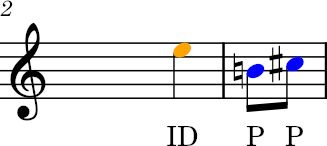

<music21.stream.Score 0x28cf2f225a0>

In [14]:
visualize_segment(segments, 1, parsed_score)

In [25]:
class MultiSegmentVisualizer:
    def __init__(self, segments, original_score, max_segments=4):
        self.segments = segments
        self.original_score = original_score
        self.max_segments = max_segments
        self.active_segments = 1
        self.segment_widgets = []
        self.current_scores = [None] * max_segments
        self.temp_midi_files = []  # Keep track of temporary files
        
        # Initialize pygame mixer for audio playback
        mixer.init()
        
        # Setup environment for music21
        self.env = environment.Environment()
        
        self.setup_widgets()
    
    def __del__(self):
        """Cleanup temporary files when the visualizer is destroyed"""
        for temp_file in self.temp_midi_files:
            if os.path.exists(temp_file):
                try:
                    os.remove(temp_file)
                except:
                    pass
    
    def create_segment_controls(self, index):
        """Create a set of controls for a single segment"""
        segment_box = widgets.VBox([
            widgets.HBox([
                widgets.Dropdown(
                    options=[(f'Segment {i}', i) for i in range(len(self.segments))],
                    value=index,
                    description=f'Segment {index + 1}:',
                    style={'description_width': 'initial'},
                    layout=widgets.Layout(width='250px')
                ),
                widgets.Button(
                    description=f'Play Segment {index + 1}',
                    button_style='success',
                    layout=widgets.Layout(width='150px')
                ),
                widgets.Button(
                    description='Stop',
                    button_style='danger',
                    layout=widgets.Layout(width='100px')
                )
            ]),
            widgets.HTML(
                value=f'<p>Select segment {index + 1} to view details</p>',
                layout=widgets.Layout(width='100%', padding='10px')
            ),
            widgets.Output()
        ])
        
        # Add play button callback
        segment_box.children[0].children[1].on_click(
            lambda b, idx=index: self.play_segment(idx)
        )
        
        # Add stop button callback
        segment_box.children[0].children[2].on_click(
            lambda b: self.stop_playback()
        )
        
        return segment_box
    
    def setup_widgets(self):
        # Create add/remove segment controls
        self.add_segment_btn = widgets.Button(
            description='Add Segment',
            button_style='info',
            layout=widgets.Layout(width='150px')
        )
        
        self.remove_segment_btn = widgets.Button(
            description='Remove Segment',
            button_style='warning',
            layout=widgets.Layout(width='150px')
        )
        
        self.update_button = widgets.Button(
            description='Update All',
            button_style='primary',
            layout=widgets.Layout(width='150px')
        )
        
        # Add callbacks
        self.add_segment_btn.on_click(self.add_segment)
        self.remove_segment_btn.on_click(self.remove_segment)
        self.update_button.on_click(self.update_visualization)
        
        # Create first segment controls
        self.segment_widgets.append(self.create_segment_controls(0))
        
        # Create control panel
        self.controls = widgets.HBox([
            self.add_segment_btn,
            self.remove_segment_btn,
            self.update_button
        ])
        
        # Layout all widgets
        self.widget_box = widgets.VBox([
            self.controls,
            widgets.VBox(self.segment_widgets)
        ])
        
        # Display the interface
        display(self.widget_box)
    
    def stop_playback(self):
        """Stop any currently playing audio"""
        mixer.music.stop()
    
    def play_segment(self, index):
        """Play audio for the specified segment"""
        if self.current_scores[index]:
            try:
                # Create a temporary file for the MIDI
                with tempfile.NamedTemporaryFile(suffix='.mid', delete=False) as tmp:
                    temp_midi_path = tmp.name
                    self.temp_midi_files.append(temp_midi_path)
                
                # Save the score as MIDI
                self.current_scores[index].write('midi', fp=temp_midi_path)
                
                # Stop any currently playing audio
                mixer.music.stop()
                
                # Load and play the new MIDI file
                mixer.music.load(temp_midi_path)
                mixer.music.play()
                
            except Exception as e:
                print(f"Error playing segment: {str(e)}")
    
    def add_segment(self, _):
        """Add a new segment comparison if under max limit"""
        if self.active_segments < self.max_segments:
            new_segment = self.create_segment_controls(self.active_segments)
            self.segment_widgets.append(new_segment)
            self.active_segments += 1
            self.widget_box.children = (
                self.controls,
                widgets.VBox(self.segment_widgets)
            )
    
    def remove_segment(self, _):
        """Remove the last segment comparison if more than one exists"""
        if self.active_segments > 1:
            removed_segment = self.segment_widgets.pop()
            self.active_segments -= 1
            self.current_scores[self.active_segments] = None
            self.widget_box.children = (
                self.controls,
                widgets.VBox(self.segment_widgets)
            )
    
    def get_segment_info(self, segment_idx):
        """Generate HTML info for a segment"""
        segment_df = self.segments[segment_idx]
        return f"""
        <div style='background-color: #f0f0f0; padding: 10px; border-radius: 5px;'>
            <h4>Segment {segment_idx} Details:</h4>
            <ul>
                <li>Number of notes: {len(segment_df)}</li>
                <li>Duration (beats): {segment_df['onset_beats'].max() - segment_df['onset_beats'].min():.2f}</li>
            </ul>
        </div>
        """
    
    def update_visualization(self, _=None):
        """Update all active segment visualizations"""
        for idx, segment_box in enumerate(self.segment_widgets):
            # Get the selected segment index from the dropdown
            selected_segment = segment_box.children[0].children[0].value
            
            # Update info
            segment_box.children[1].value = self.get_segment_info(selected_segment)
            
            # Update visualization
            with segment_box.children[2]:
                clear_output(wait=True)
                self.current_scores[idx] = visualize_segment(
                    self.segments,
                    selected_segment,
                    self.original_score,
                    show_score=False
                )
                self.current_scores[idx].show()


In [26]:
MultiSegmentVisualizer(segments, parsed_score, 5)

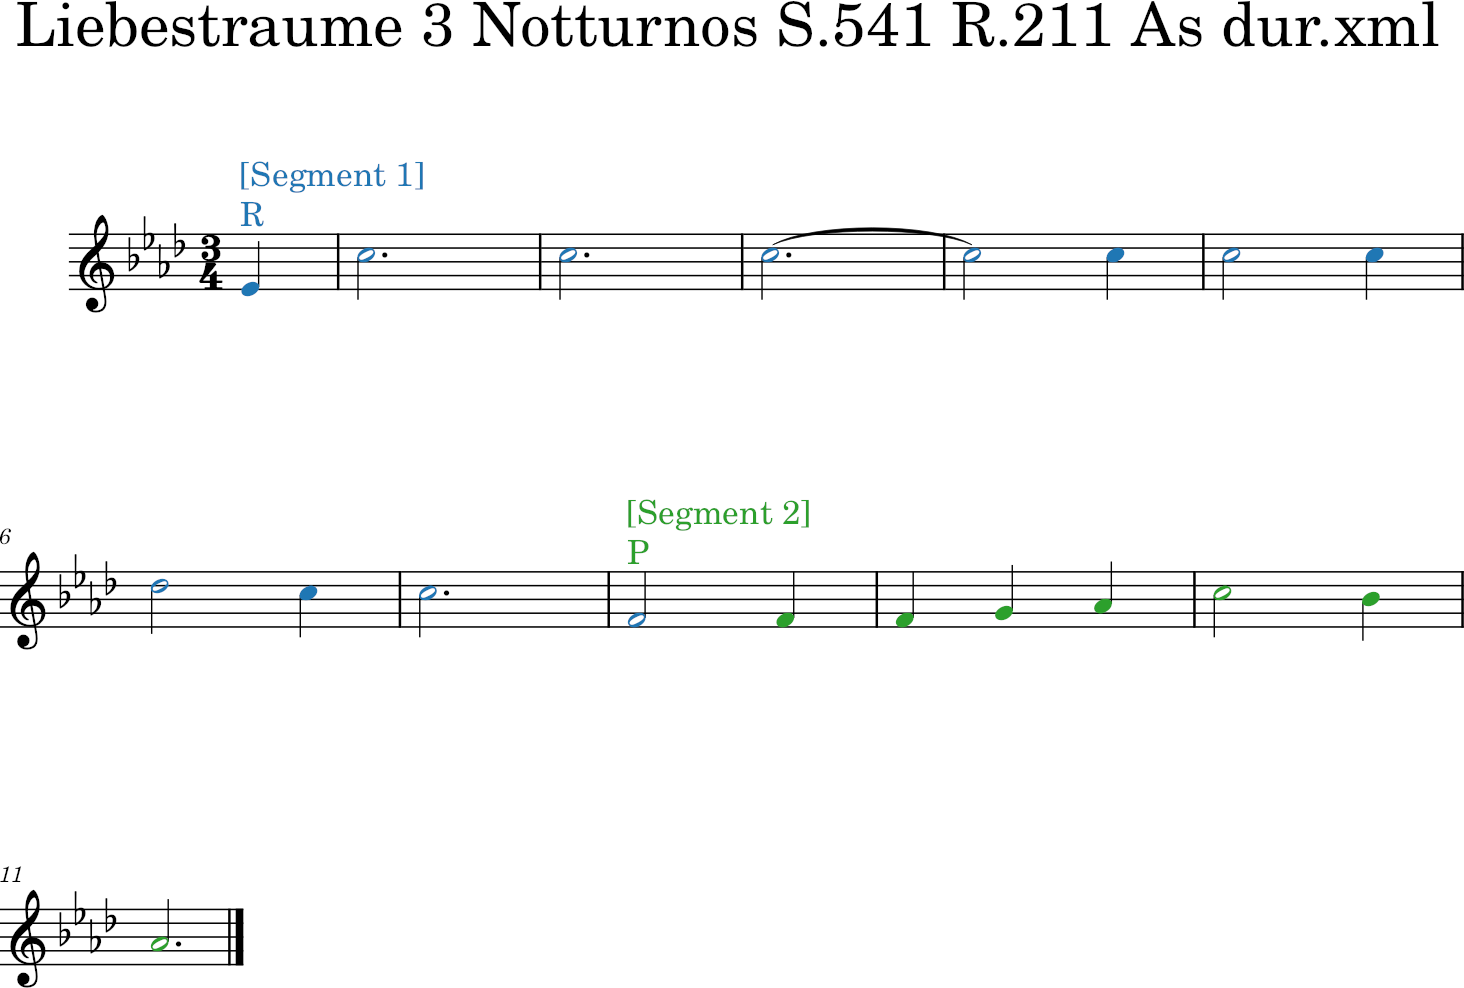

In [115]:
annotated_score = visualize_score_with_segment_labels(parsed_score, segments)
colored_score = visualize_score_with_colored_segments(parsed_score, segments)
colored_score.show()

In [27]:
prepped_segments = preprocess_segments(segments)

In [22]:
segments

[    onset_beats  onset_beats_in_measure  duration_beats  midi_pitch  \
 0           0.0                     0.0             0.5        71.0   
 1           0.5                     0.5             0.5        73.0   
 2           1.0                     1.0             0.5        74.0   
 3           1.5                     1.5             0.5        76.0   
 4           2.0                     2.0             0.5        78.0   
 5           2.5                     2.5             0.5        74.0   
 6           3.0                     3.0             1.0        78.0   
 7           4.0                     0.0             0.5        77.0   
 8           4.5                     0.5             0.5        73.0   
 9           5.0                     1.0             1.0        77.0   
 10          6.0                     2.0             0.5        76.0   
 11          6.5                     2.5             0.5        72.0   
 
     pitch_class  octave  beat_strength ir_symbol  pattern_ind

In [28]:
dmat = segments_to_distance_matrix(prepped_segments)

Calculated Edge Weight (0, 1)
Calculated Edge Weight (0, 2)
Calculated Edge Weight (0, 3)
Calculated Edge Weight (0, 4)
Calculated Edge Weight (0, 5)
Calculated Edge Weight (0, 6)
Calculated Edge Weight (0, 7)
Calculated Edge Weight (0, 8)
Calculated Edge Weight (0, 9)
Calculated Edge Weight (0, 10)
Calculated Edge Weight (0, 11)
Calculated Edge Weight (0, 12)
Calculated Edge Weight (0, 13)
Calculated Edge Weight (0, 14)
Calculated Edge Weight (0, 15)
Calculated Edge Weight (0, 16)
Calculated Edge Weight (0, 17)
Calculated Edge Weight (0, 18)
Calculated Edge Weight (0, 19)
Calculated Edge Weight (0, 20)
Calculated Edge Weight (1, 2)
Calculated Edge Weight (1, 3)
Calculated Edge Weight (1, 4)
Calculated Edge Weight (1, 5)
Calculated Edge Weight (1, 6)
Calculated Edge Weight (1, 7)
Calculated Edge Weight (1, 8)
Calculated Edge Weight (1, 9)
Calculated Edge Weight (1, 10)
Calculated Edge Weight (1, 11)
Calculated Edge Weight (1, 12)
Calculated Edge Weight (1, 13)
Calculated Edge Weight (1

In [18]:
dmat

array([[ 0.        , 13.70504013, 15.21255649,  5.46151307, 12.54741009,
        16.34873848,  6.92820323, 15.35669642, 16.8351381 ,  8.82202499,
        14.33309108, 16.30567386, 16.18351785, 16.55200139, 16.18351785,
        16.55200139,  3.46410162, 14.13605762, 15.60198305,  6.46746666,
        19.63853037, 25.11660307, 31.6044894 , 23.71807064, 31.24299922],
       [13.70504013,  0.        , 13.14403382, 12.93976429,  4.36963957,
        13.21043622, 15.35669642,  3.46410162, 14.37989047, 14.40269072,
         6.564583  , 13.87556305, 18.29361227, 15.99707004, 18.29361227,
        15.99707004, 14.13605762,  1.73205081, 13.40767038, 13.3205668 ,
        17.24048651, 25.3968502 , 33.14362684, 25.28061263, 31.99707018],
       [15.21255649, 13.14403382,  0.        , 12.627475  , 11.75996918,
         5.85368474, 17.07108301, 14.99218546,  6.63324958, 14.6783216 ,
        13.79481334,  6.94734662, 15.86564685, 16.5864214 , 15.86564685,
        16.5864214 , 15.72964955, 13.70275976,  3

In [46]:
segments_to_distance_matrix(prepped_segments)

Calculated Edge Weight (0, 1)
Calculated Edge Weight (0, 2)
Calculated Edge Weight (0, 3)
Calculated Edge Weight (1, 2)
Calculated Edge Weight (1, 3)
Calculated Edge Weight (2, 3)


array([[ 0.        ,  8.4723816 , 15.24385122,         nan],
       [ 8.4723816 ,  0.        , 16.92215633,         nan],
       [15.24385122, 16.92215633,  0.        ,         nan],
       [        nan,         nan,         nan,  0.        ]])

In [31]:
prepped_segments[3]

,onset_beats_in_measure,duration_beats,pitch_class,octave,beat_strength,ir_symbol_P,ir_symbol_D,ir_symbol_IP,ir_symbol_ID,ir_symbol_VP,ir_symbol_R,ir_symbol_IR,ir_symbol_VR,ir_symbol_M,ir_symbol_d,ir_symbol_rest
26,0.0,0.5,11.0,4.0,1.000,1,0,0,0,0,0,0,0,0,0,0
27,0.5,0.5,1.0,5.0,0.125,1,0,0,0,0,0,0,0,0,0,0
28,1.0,0.5,2.0,5.0,0.250,1,0,0,0,0,0,0,0,0,0,0
29,1.5,0.5,4.0,5.0,0.125,1,0,0,0,0,0,0,0,0,0,0
30,2.0,0.5,6.0,5.0,0.500,0,0,0,1,0,0,0,0,0,0,0
31,2.5,0.5,2.0,5.0,0.125,0,0,0,1,0,0,0,0,0,0,0
32,3.0,1.0,6.0,5.0,0.250,0,0,0,1,0,0,0,0,0,0,0
33,0.0,0.5,5.0,5.0,1.000,0,0,0,1,0,0,0,0,0,0,0
34,0.5,0.5,1.0,5.0,0.125,0,0,0,1,0,0,0,0,0,0,0
35,1.0,1.0,5.0,5.0,0.250,0,0,0,1,0,0,0,0,0,0,0


In [23]:
mountainking = parse_segments("..\\distmat.txt")


In [25]:
mountainking

array([[ 0.        , 12.5       , 16.74066904, 12.02081528, 11.54339638,
        11.18033989,  6.5       , 13.91941091, 13.52774926,  0.        ,
        12.5       , 13.82027496, 10.27131929, 16.93369422, 10.27131929,
        19.1245915 , 12.02081528, 11.54339638, 12.72792206,  6.80073525,
        18.60779407],
       [12.5       ,  0.        , 15.32155345,  9.82344135,  5.43139025,
         7.41619849, 13.05756486,  6.18465844, 12.32882801, 12.5       ,
         0.        , 12.63922466, 13.44432966, 16.69580786, 13.44432966,
        18.80824287,  9.82344135,  5.43139025,  8.94427191, 12.10371844,
        15.94521872],
       [16.74066904, 15.32155345,  0.        , 10.59481005, 14.47411483,
        13.82931669, 16.53027525, 12.09338662,  6.5       , 16.74066904,
        15.32155345,  5.56776436, 15.74007624, 14.22146265, 15.74007624,
        13.12440475, 10.59481005, 14.47411483,  8.01560977, 15.53222457,
        15.58043645],
       [12.02081528,  9.82344135, 10.59481005,  0.        

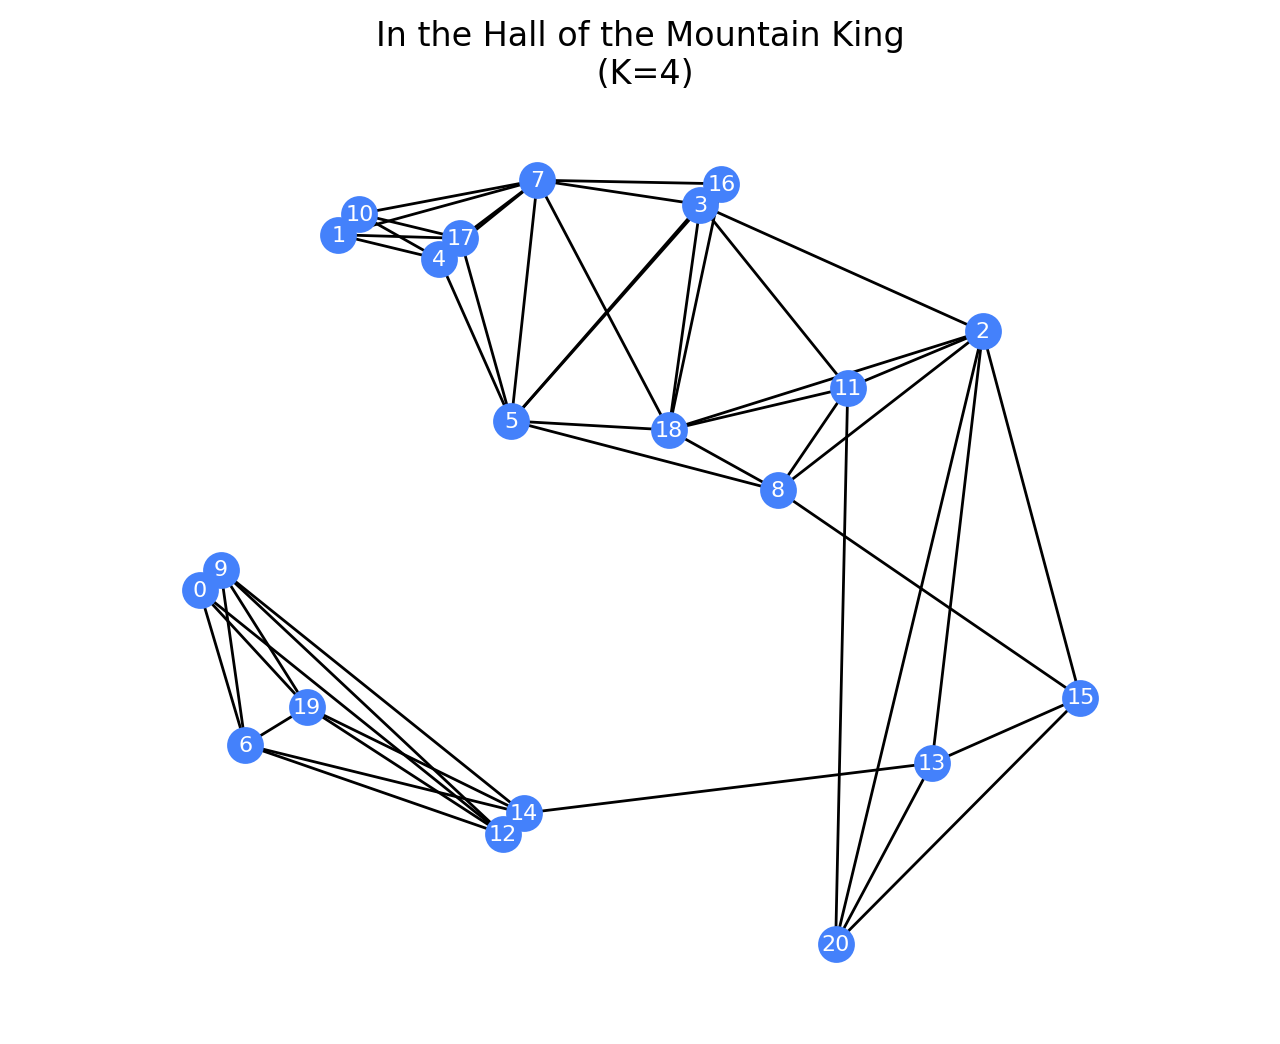

In [24]:
distance_matrix_to_knn_graph_scaled(4, mountainking, "In the Hall of the Mountain King\n", 69)

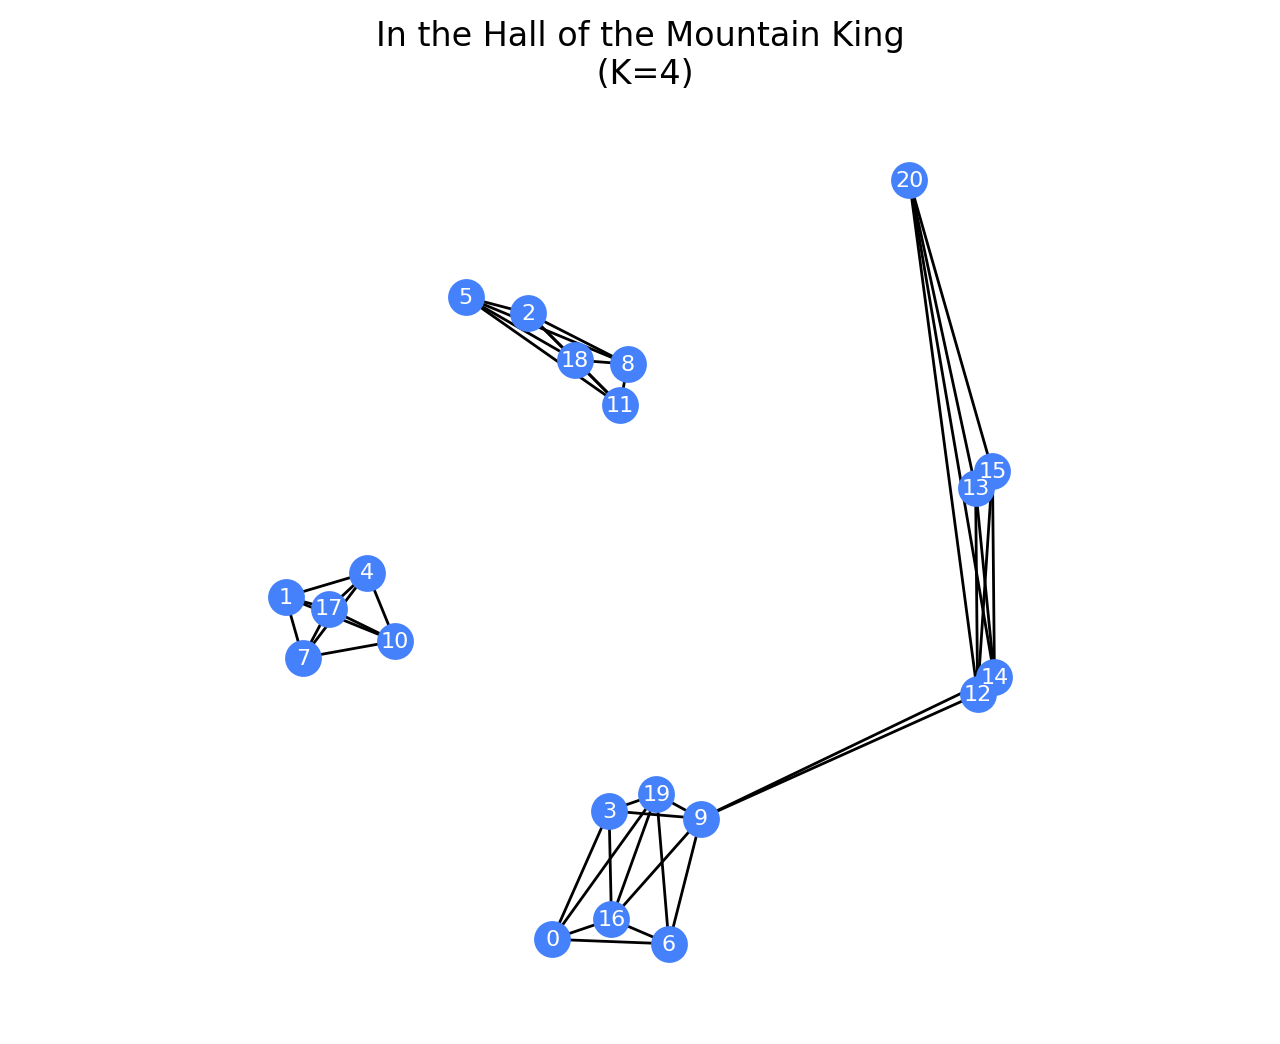

In [29]:
distance_matrix_to_knn_graph_scaled(4, dmat, "In the Hall of the Mountain King\n", 69)

In [30]:
MultiSegmentVisualizer(segments, parsed_score, 5)

In [19]:
with open('.\\pickled\\bach_cello_segments.pkl', 'rb') as file:
    bach_cello_segments = pickle.load(file)

In [23]:
bach_cello_segments['Suite No. 1 in G major']

[     onset_beats  duration_beats  midi_pitch  ir_symbol_P  ir_symbol_D  \
 0           0.00            0.25        43.0            1            0   
 1           0.25            0.25        50.0            1            0   
 2           0.50            0.25        59.0            1            0   
 3           0.75            0.25        57.0            0            0   
 4           1.00            0.25        59.0            0            0   
 ..           ...             ...         ...          ...          ...   
 133        33.25            0.25        49.0            1            0   
 134        33.50            0.25        47.0            1            0   
 135        33.75            0.25        45.0            0            0   
 136        34.00            0.25        55.0            0            0   
 137        34.25            0.25        54.0            0            0   
 
      ir_symbol_IP  ir_symbol_ID  ir_symbol_VP  ir_symbol_R  ir_symbol_IR  \
 0               0   

In [37]:
bach_cello_segments['Suite No. 1 in G major']

list

In [36]:
prepped_segments

[   onset_beats_in_measure  duration_beats  pitch_class  octave  beat_strength  \
 0                     0.0             2.0          6.0     5.0          1.000   
 1                     2.0             0.5         11.0     4.0          0.500   
 2                     2.5             0.5          1.0     5.0          0.125   
 3                     3.0             0.5          2.0     5.0          0.250   
 4                     3.5             0.5          4.0     5.0          0.125   
 5                     0.0             1.5          6.0     5.0          1.000   
 6                     1.5             0.5          2.0     5.0          0.125   
 
    ir_symbol_P  ir_symbol_D  ir_symbol_IP  ir_symbol_ID  ir_symbol_VP  \
 0            0            0             0             0             0   
 1            1            0             0             0             0   
 2            1            0             0             0             0   
 3            1            0             0    

In [38]:
segments_to_distance_matrix(bach_cello_segments['Suite No. 1 in G major'])

In [39]:
segments_to_distance_matrices(bach_cello_segments)

Composer: Suite No. 1 in G major | Segments: 214
Composer: Suite No. 2 in D minor | Segments: 242
Composer: Suite No. 3 in C major | Segments: 316
Composer: Suite No. 4 in Eb major | Segments: 349
Composer: Suite No. 5 in C minor | Segments: 285
Composer: Suite No. 6 in D major | Segments: 368


{'Suite No. 1 in G major': None,
 'Suite No. 2 in D minor': None,
 'Suite No. 3 in C major': None,
 'Suite No. 4 in Eb major': None,
 'Suite No. 5 in C minor': None,
 'Suite No. 6 in D major': None}

In [ ]:
print("All Elements:")
for i, elem in enumerate(x.recurse()):
    print(f"Element {i}:")
    print(f"  Class: {elem.__class__.__name__}")
    print(f"  ID: {id(elem)}")
    if isinstance(elem, music21.expressions.TextExpression):
        print(f"  Text Content: {elem.content}")
    if hasattr(elem, 'partName'):
        print(f"  Part Name: {elem.partName}")
    if hasattr(elem, '_partName'):
        print(f"  _Part Name: {elem._partName}")
    print(f"  Properties:", end=" ")
    if hasattr(elem, 'name'):
        print(f"name={elem.name}", end=" ")
    if hasattr(elem, 'offset'):
        print(f"offset={elem.offset}", end=" ")
    print("\n")


print("\nMeasure Contents:")
for part in x.parts:
    for measure in part.getElementsByClass('Measure'):
        print(f"\nMeasure at offset {measure.offset}:")
        for elem in measure:
            print(f"  - {elem.__class__.__name__}")
            if isinstance(elem, music21.expressions.TextExpression):
                print(f"    Content: {elem.content}")
                
# Method 2: Look specifically for text-related elements
print("\nText-related elements:")
for elem in x.recurse():
    if isinstance(elem, (music21.expressions.TextExpression, 
                       music21.metadata.Metadata, 
                       music21.text.TextBox,
                       music21.expressions.Expression)):
        print(f"Found text element:")
        print(f"  Type: {type(elem)}")
        print(f"  Content: {elem}")
        # print(f"  Parent: {elem.parent}")
        print()

# Method 3: Check score metadata
print("\nScore metadata:")
if x.metadata:
    for key in dir(x.metadata):
        if not key.startswith('_'):  # Skip private attributes
            value = getattr(x.metadata, key)
            if not callable(value):  # Skip methods
                print(f"  {key}: {value}")

# Method 4: Check part-level information
print("\nPart information:")
for i, part in enumerate(x.parts):
    print(f"\nPart {i}:")
    print(f"  Part ID: {part.id}")
    print(f"  Part Group: {part.groups}")
    if hasattr(part, 'partName'):
        print(f"  Part Name: {part.partName}")